# Importação dos Dados

In [60]:
import pandas as pd

df_clinico = pd.read_csv('csv/internamentos_respiratorios_palmas.csv')
df_climatico = pd.read_csv('csv/particulas_ar_palmas.csv')
df_temperatura = pd.read_csv('csv/dados_climaticos.csv')


df_clinico['DT_INTER'] = pd.to_datetime(df_clinico["DT_INTER"]).dt.normalize()
df_climatico['time'] = pd.to_datetime(df_climatico["time"]).dt.normalize()
df_temperatura['time'] = pd.to_datetime(df_temperatura["time"]).dt.normalize()


df_clinico_diario = df_clinico.groupby('DT_INTER').size().reset_index(name='total_internamentos')
df_climatico_diario = df_climatico.groupby('time')['pm2p5'].mean().reset_index()
df_temperatura_diaria = df_temperatura.groupby('time')['t2m'].mean().reset_index()

df_clinico_diario = df_clinico_diario.rename(columns={'DT_INTER': 'data'})
df_climatico_diario = df_climatico_diario.rename(columns={'time': 'data'})
df_temperatura_diaria = df_temperatura_diaria.rename(columns={'time': 'data'})
df_temperatura_diaria = df_temperatura_diaria.rename(columns={'t2m': 'temperatura'})


df_final = pd.merge(df_clinico_diario, df_climatico_diario, on='data', how='inner')

df_final = pd.merge(df_final, df_temperatura_diaria, on='data', how='inner')
df_final

,data,total_internamentos,pm2p5,temperatura
0,2007-09-05,1,1.188463e-08,19.530975
1,2007-09-07,1,1.335781e-08,19.101654
2,2007-09-09,1,1.323928e-08,19.592804
3,2007-09-10,1,1.283946e-08,18.813934
4,2007-09-12,1,2.482241e-08,18.956512
...,...,...,...,...
4893,2024-12-15,1,5.265750e-09,17.977081
4894,2024-12-16,1,2.680921e-09,16.507538
4895,2024-12-17,1,2.493791e-09,17.405060
4896,2024-12-20,2,3.008121e-09,18.929962


# Autocorrelação

## Dados Diários

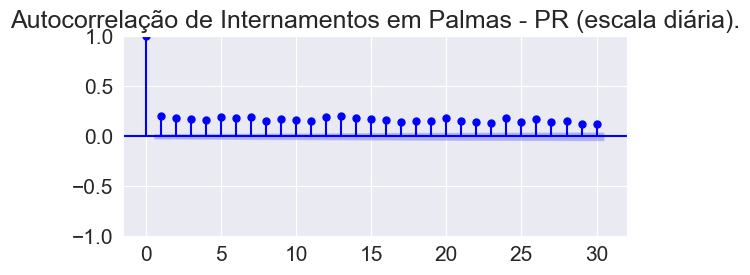

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# 1. Garante que a coluna 'data' seja do tipo datetime
df_final['data'] = pd.to_datetime(df_final['data'])

fig, ax = plt.subplots(figsize=(6, 3))

plot_acf(df_final["total_internamentos"], ax=ax, lags=30)
ax.set_title("Autocorrelação de Internamentos em Palmas - PR (escala diária).")

plt.tight_layout()
plt.show()

## Dados Mensais

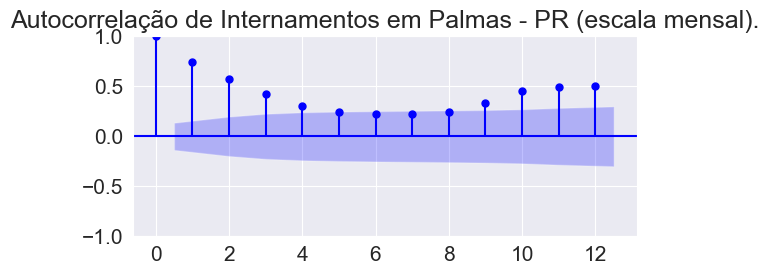

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# 1. Garante que a coluna 'data' seja do tipo datetime
df_final['data'] = pd.to_datetime(df_final['data'])

# 2. Agrupa os dados por mês
df_mensal = df_final.groupby(pd.Grouper(key='data', freq='ME')).agg({
    'total_internamentos': 'sum',
    'pm2p5': 'mean',
    'temperatura': 'mean'
}).reset_index()

fig, ax = plt.subplots(figsize=(6, 3))
plot_acf(df_mensal["total_internamentos"], ax=ax, lags=12)
ax.set_title("Autocorrelação de Internamentos em Palmas - PR (escala mensal).")

plt.tight_layout()
plt.show()

## Dados Anuais

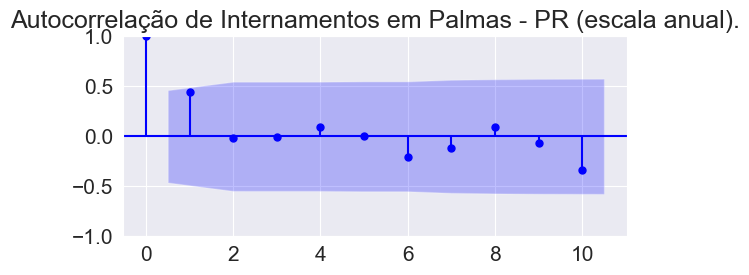

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# 1. Garante que a coluna 'data' seja do tipo datetime
df_final['data'] = pd.to_datetime(df_final['data'])

# 2. Agrupa os dados por ano
df_anual = df_final.groupby(pd.Grouper(key='data', freq='YE')).agg({
    'total_internamentos': 'sum',
    'pm2p5': 'mean',
    'temperatura': 'mean'
}).reset_index()

fig, ax = plt.subplots(figsize=(6, 3))
plot_acf(df_anual["total_internamentos"], ax=ax, lags=10)
ax.set_title("Autocorrelação de Internamentos em Palmas - PR (escala anual).")

plt.tight_layout()
plt.show()

# Correlação entre Variáveis

## Dados Diários

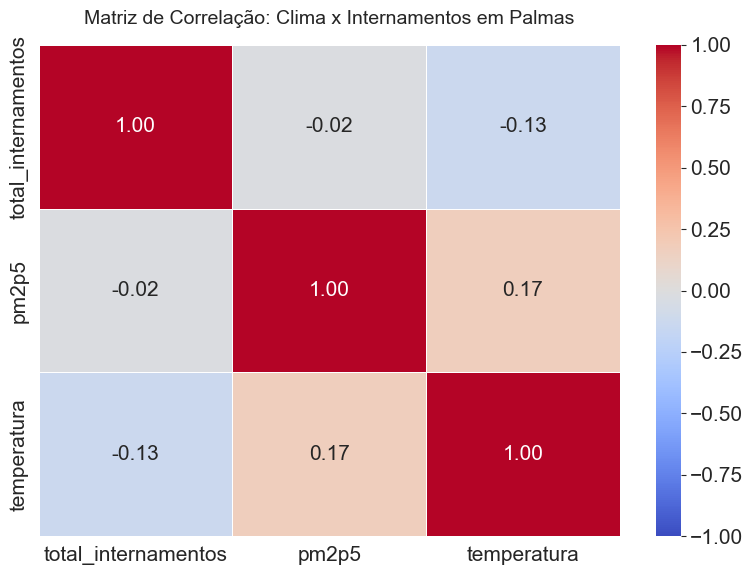

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Garante que a coluna 'data' seja do tipo datetime
df_final['data'] = pd.to_datetime(df_final['data'])

# 2. seleciona as colunas
df_diario = df_final[['total_internamentos', 'pm2p5', 'temperatura']]

# 3. Calcula a matriz de correlação de Pearson
matriz_correlacao = df_diario.corr()

# 4. Plota o Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)

plt.title('Matriz de Correlação: Clima x Internamentos em Palmas', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

## Dados Mensais

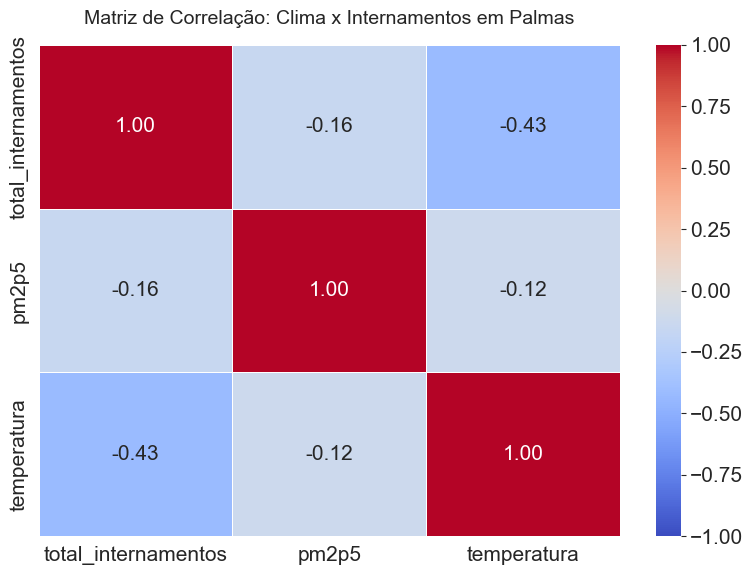

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Garante que a coluna 'data' seja do tipo datetime
df_final['data'] = pd.to_datetime(df_final['data'])

# 2. Agrupa os dados por mês
df_mensal = df_final.groupby(pd.Grouper(key='data', freq='ME')).agg({
    'total_internamentos': 'sum',
    'pm2p5': 'mean',
    'temperatura': 'mean'
}).reset_index()

# 3. seleciona as colunas
df_mensal = df_mensal[['total_internamentos', 'pm2p5', 'temperatura']]

# 4. Calcula a matriz de correlação de Pearson
matriz_correlacao = df_mensal.corr()

# 5. Plota o Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)

plt.title('Matriz de Correlação: Clima x Internamentos em Palmas', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

## Dados Anuais

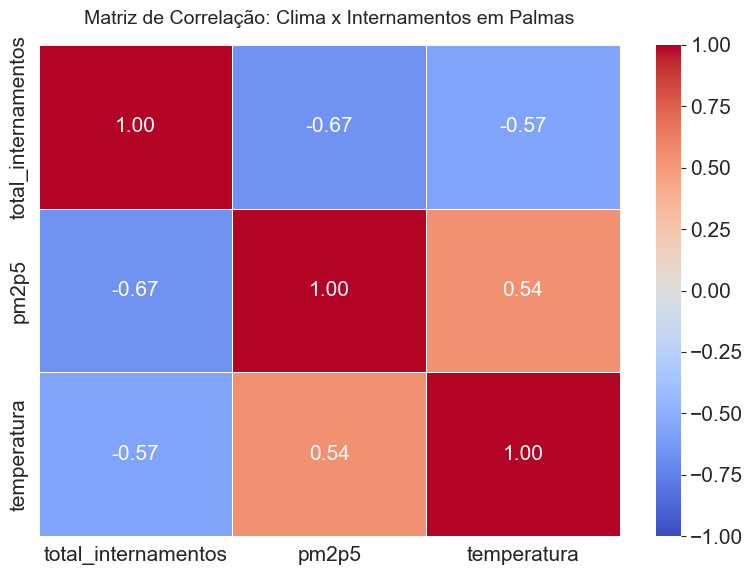

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Garante que a coluna 'data' seja do tipo datetime
df_final['data'] = pd.to_datetime(df_final['data'])

# 2. Agrupa os dados por ano
df_anual = df_final.groupby(pd.Grouper(key='data', freq='YE')).agg({
    'total_internamentos': 'sum',
    'pm2p5': 'mean',
    'temperatura': 'mean'
}).reset_index()

# 3. seleciona as colunas
df_anual = df_anual[['total_internamentos', 'pm2p5', 'temperatura']]

# 4. Calcula a matriz de correlação de Pearson
matriz_correlacao = df_anual.corr()

# 5. Plota o Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)

plt.title('Matriz de Correlação: Clima x Internamentos em Palmas', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Correlação entre Variáveis atrasadas

## Dados Diários

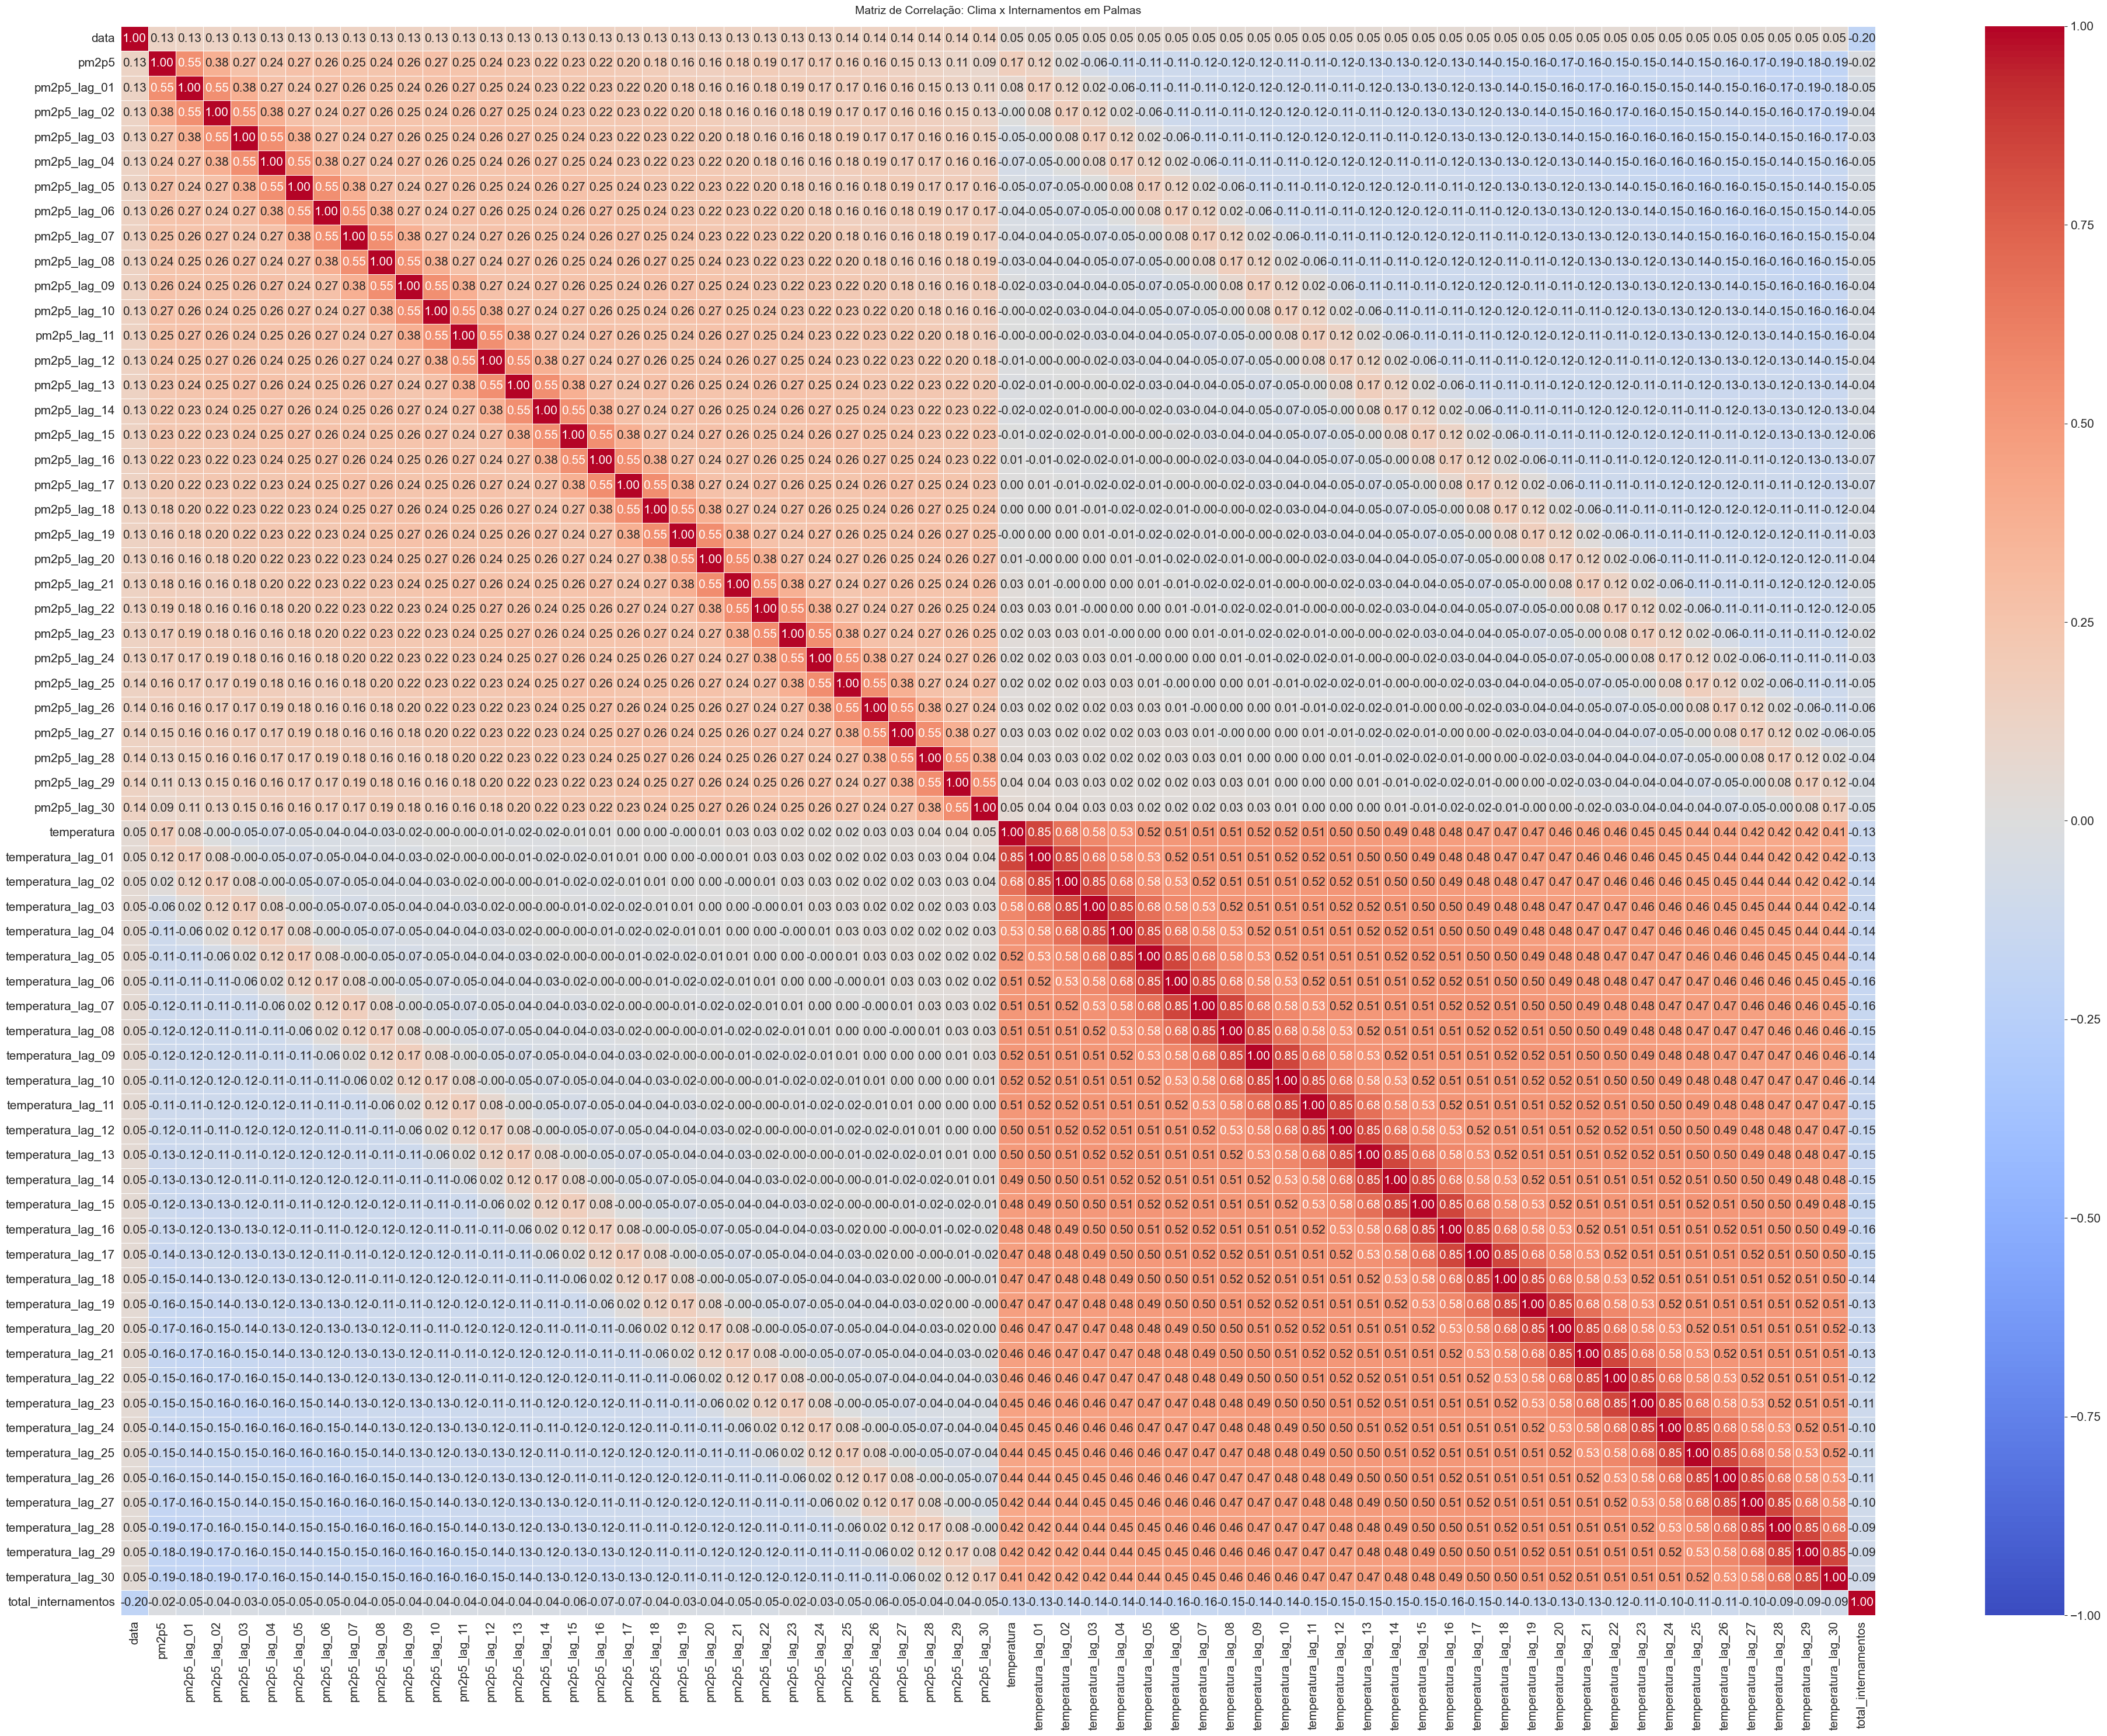

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ordenar obrigatoriamente por data para garantir a cronologia
df_diario = df_final.sort_values(by='data').reset_index(drop=True)

# 2. Definir a quantidade de dias de defasagem (lags) desejados
dias_lag = range(1, 31)

# 3. Criar as colunas de lag iterando sobre os dias
for i in dias_lag:
    # Lags para o material particulado (PM2.5)
    df_diario[f'pm2p5_lag_{i:02d}'] = df_diario['pm2p5'].shift(i)

    # Lags para a temperatura
    df_diario[f'temperatura_lag_{i:02d}'] = df_diario['temperatura'].shift(i)

df_diario = df_diario.sort_index(axis=1)

# 4. Calcula a matriz de correlação de Pearson
matriz_correlacao = df_diario.corr()

# 5. Plota o Heatmap
plt.figure(figsize=(40, 30))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)

plt.title('Matriz de Correlação: Clima x Internamentos em Palmas', fontsize=14, pad=15)
plt.tight_layout()
plt.show()


## Dados Mensais

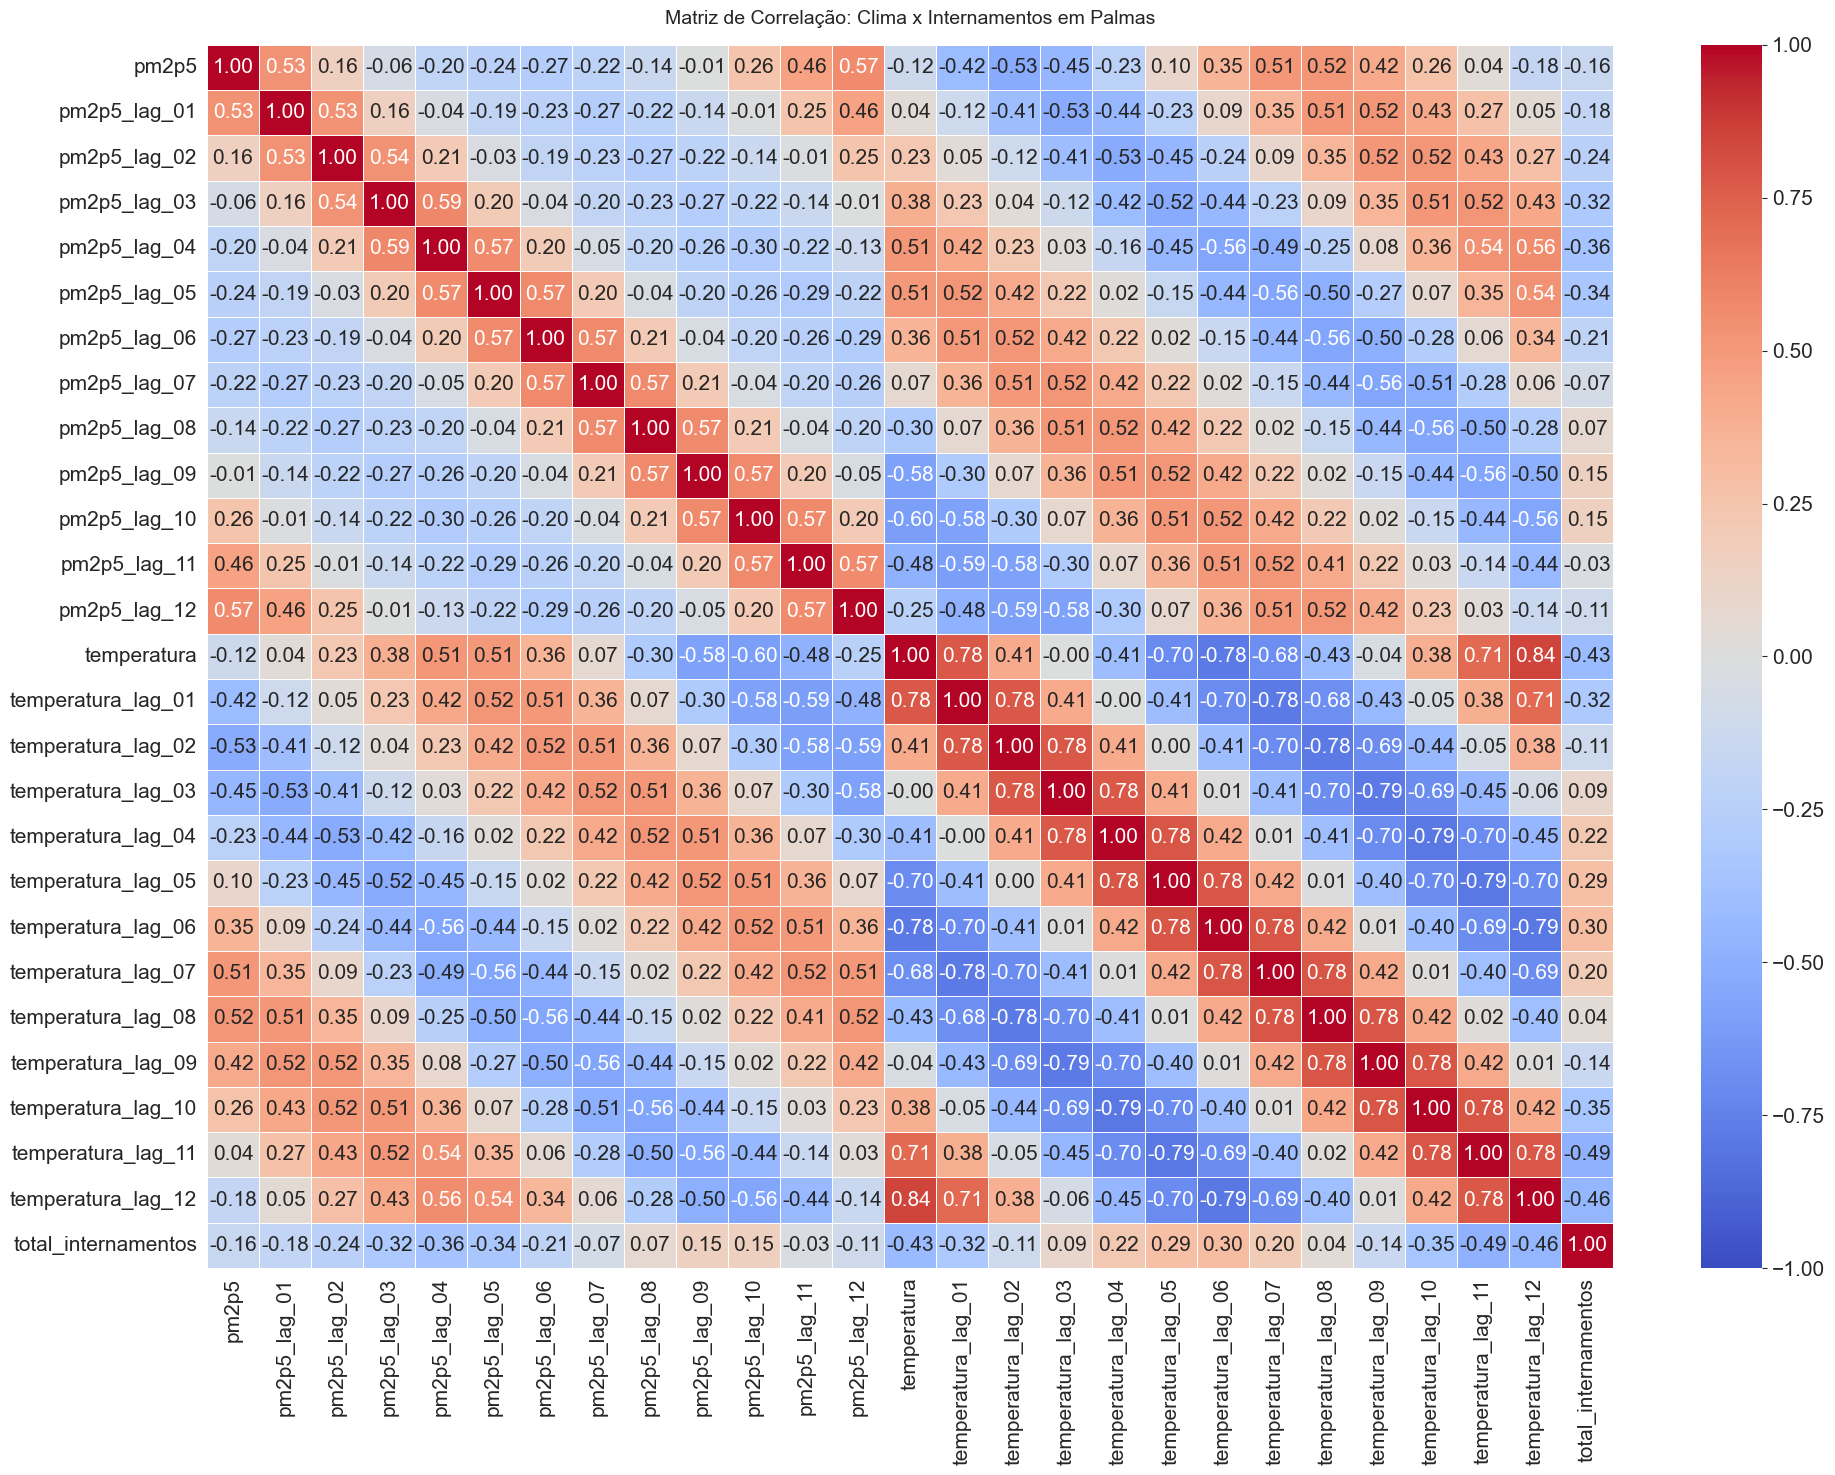

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Garanta que a coluna 'data' é do tipo datetime
df_final['data'] = pd.to_datetime(df_final['data'])

# 1. Agrupar para escala mensal
df_mensal = df_final.groupby(pd.Grouper(key='data', freq='ME')).agg({
    'total_internamentos': 'sum', # Soma os internamentos do mês
    'pm2p5': 'mean',              # Média da poluição no mês
    'temperatura': 'mean'         # Média da temperatura no mês
}).reset_index()

# 2. Ordenar obrigatoriamente por data para garantir a cronologia
df_mensal = df_mensal.sort_values(by='data').reset_index(drop=True)
df_mensal = df_mensal.drop(columns=['data'])

# 3. Definir a quantidade de meses de defasagem (lags) desejados (1 a 12 meses)
meses_lag = range(1, 13)

# 4. Criar as colunas de lag iterando sobre os meses
for i in meses_lag:
    # Lags para o material particulado (PM2.5)
    df_mensal[f'pm2p5_lag_{i:02d}'] = df_mensal['pm2p5'].shift(i)

    # Lags para a temperatura
    df_mensal[f'temperatura_lag_{i:02d}'] = df_mensal['temperatura'].shift(i)

df_mensal = df_mensal.sort_index(axis=1)

# 5. Calcula a matriz de correlação de Pearson
matriz_correlacao = df_mensal.corr()

# 6. Plota o Heatmap
plt.figure(figsize=(20, 15))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)

plt.title('Matriz de Correlação: Clima x Internamentos em Palmas', fontsize=14, pad=15)
plt.tight_layout()
plt.show()


## Dados Anuais

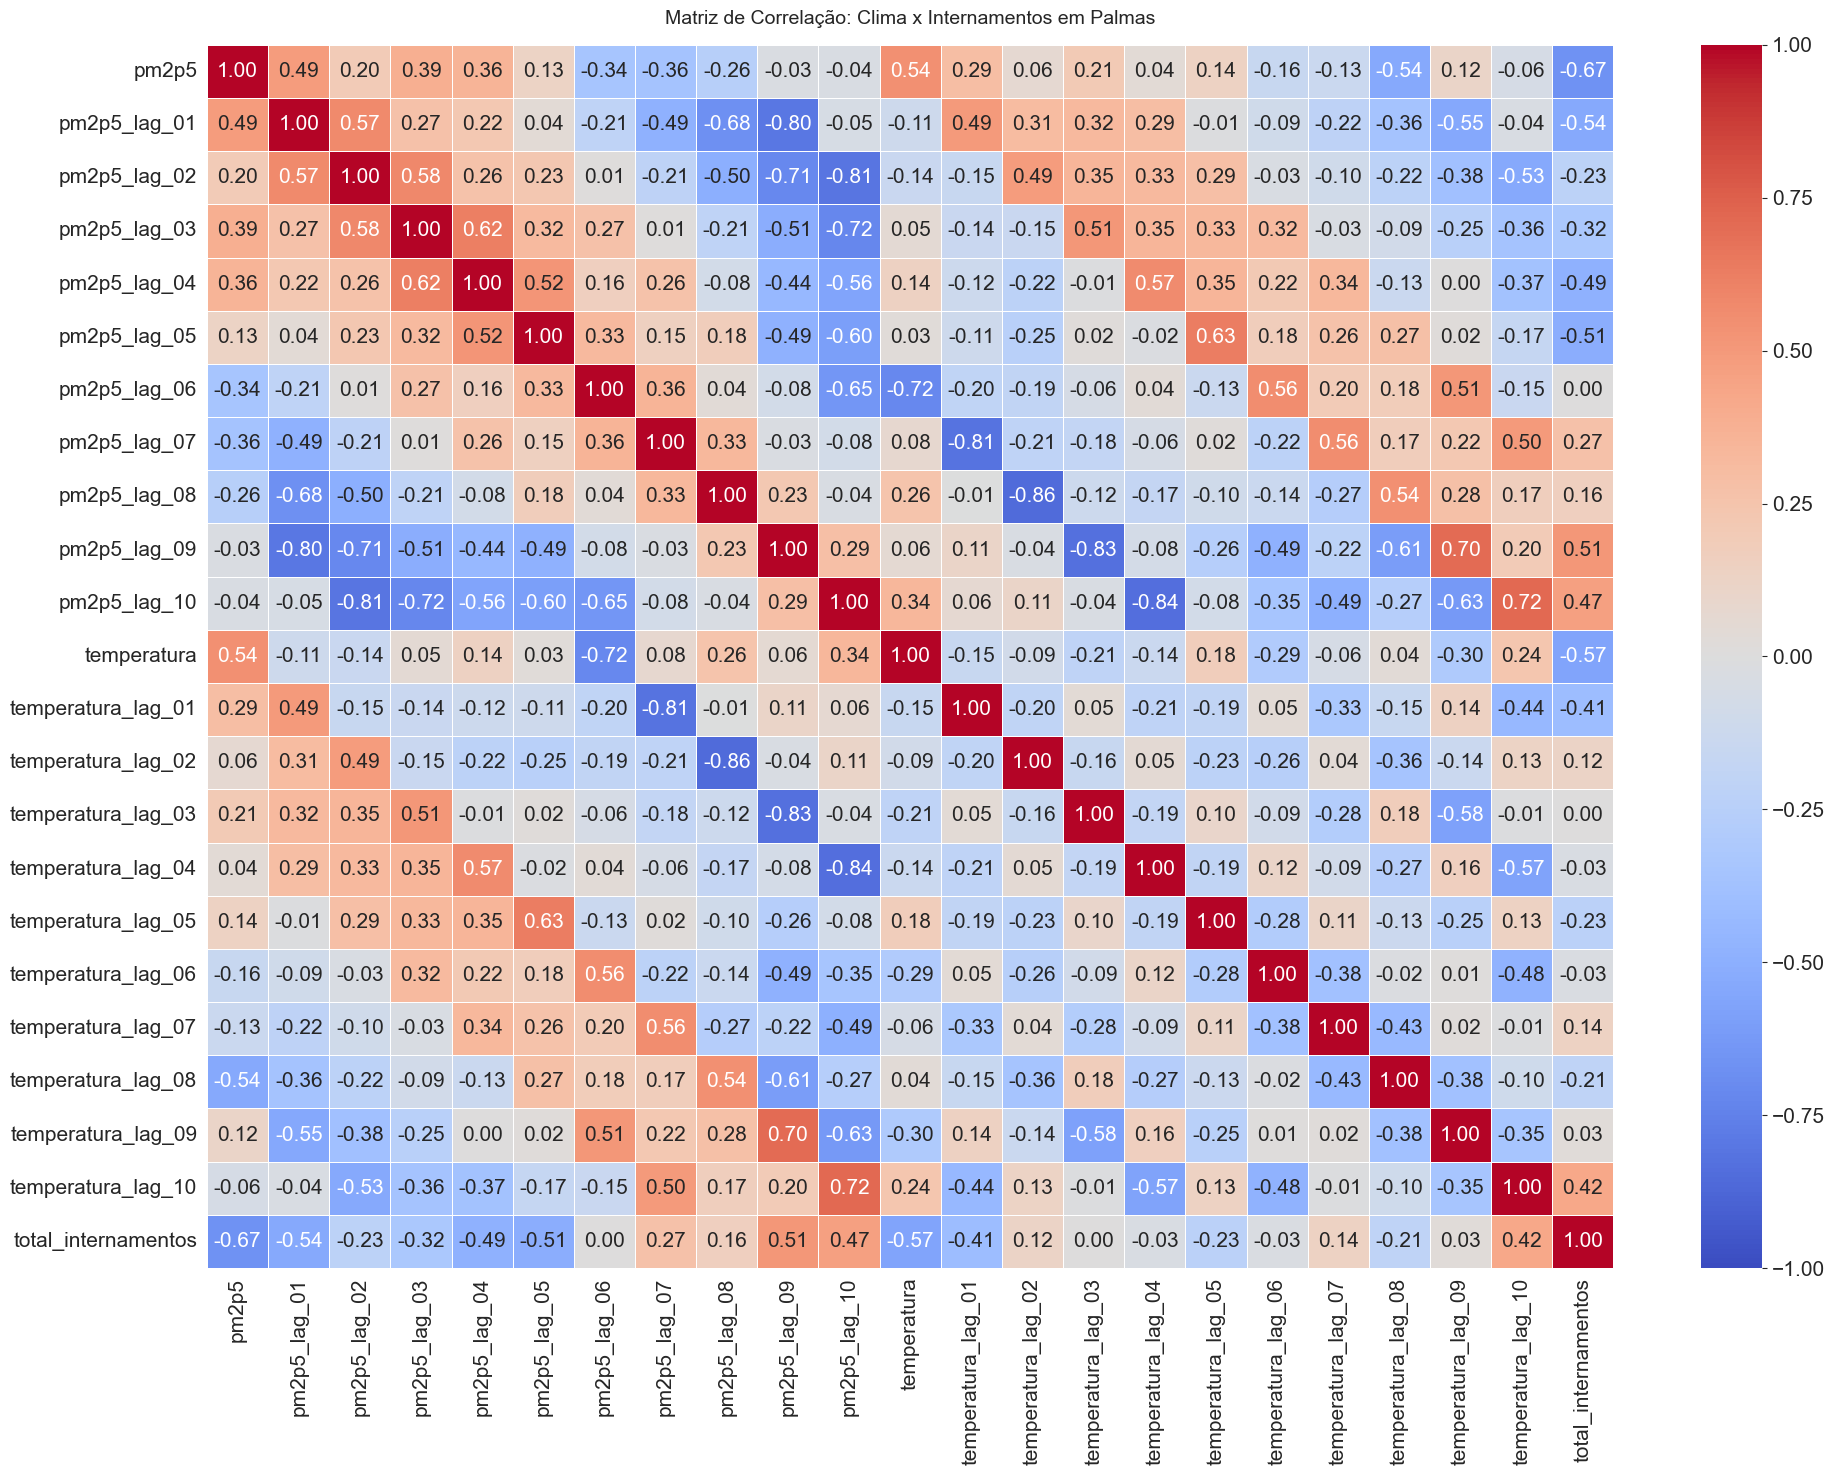

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Garanta que a coluna 'data' é do tipo datetime
df_final['data'] = pd.to_datetime(df_final['data'])

# 1. Agrupar para escala anual
df_anual = df_final.groupby(pd.Grouper(key='data', freq='YE')).agg({
    'total_internamentos': 'sum', # Soma os internamentos do ano
    'pm2p5': 'mean',              # Média da poluição no ano
    'temperatura': 'mean'         # Média da temperatura no ano
}).reset_index()

# 2. Ordenar obrigatoriamente por data para garantir a cronologia
df_anual = df_anual.sort_values(by='data').reset_index(drop=True)
df_anual = df_anual.drop(columns=['data'])

# 3. Definir a quantidade de anos de defasagem (lags)
anos_lag = range(1, 11)

# 4. Criar as colunas de lag iterando sobre os anos
for i in anos_lag:
    # Lags para o material particulado (PM2.5)
    df_anual[f'pm2p5_lag_{i:02d}'] = df_anual['pm2p5'].shift(i)

    # Lags para a temperatura
    df_anual[f'temperatura_lag_{i:02d}'] = df_anual['temperatura'].shift(i)

df_anual = df_anual.sort_index(axis=1)

# 5. Calcula a matriz de correlação de Pearson
matriz_correlacao = df_anual.corr()

# 6. Plota o Heatmap
plt.figure(figsize=(20, 15))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)

plt.title('Matriz de Correlação: Clima x Internamentos em Palmas', fontsize=14, pad=15)
plt.tight_layout()
plt.show()
